# 0. Librairies

In [1]:
from utils import *
from ddpm import *

# 1. Datasets

## 1.1. Load data

In [2]:
dataset_repertory = '/home/johnny/Diffusion model - Generation of turbulence time series/datasets/'
dataset_name = 'Lagr_u1c_diffusion-demo.h5'
normalized = False

velocities, max, min = load_data(dataset_repertory, dataset_name, normalized=normalized)
velocities.shape

(768, 1, 2000)

In [3]:
# PARAMETERS
training_size = 0.8
validation_size = 0.1

# Split into training, validation and test sets and normalize them
velocities = th.tensor(velocities)
train, validation, test = training_test_split(velocities, training_size=training_size, validation_size=validation_size)
print(f"train shape : {train.shape} | validation shape : {validation.shape} | test shape : {test.shape}")

train shape : torch.Size([614, 1, 2000]) | validation shape : torch.Size([76, 1, 2000]) | test shape : torch.Size([78, 1, 2000])


## 1.2. Data Analysis

### 1.2.1. Time-series

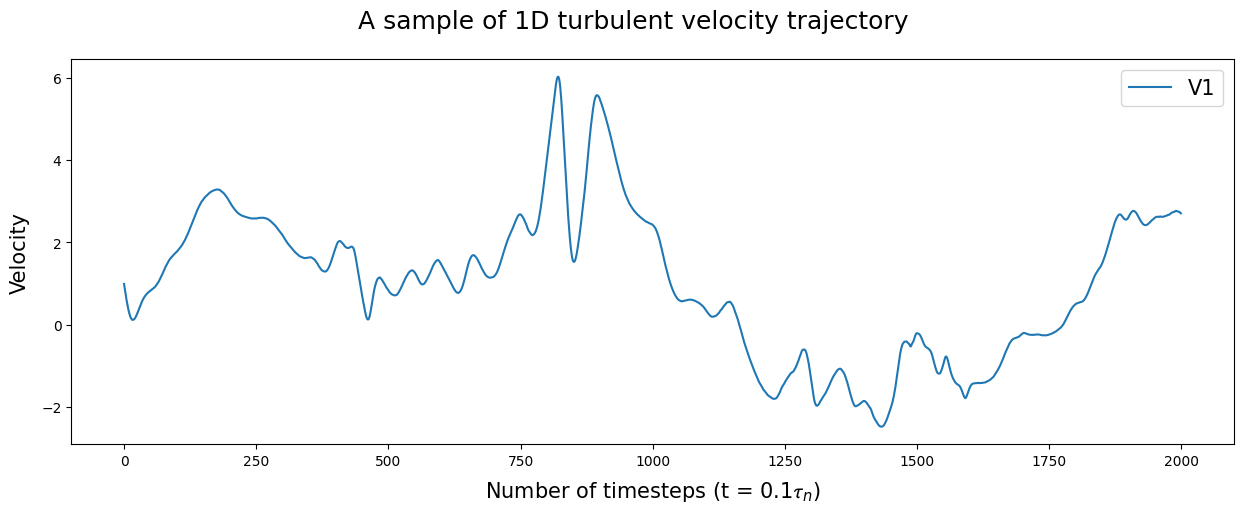

In [5]:
plot_time_series(velocities[0])

### 1.2.2. Probability density function (PDF) of velocity increments

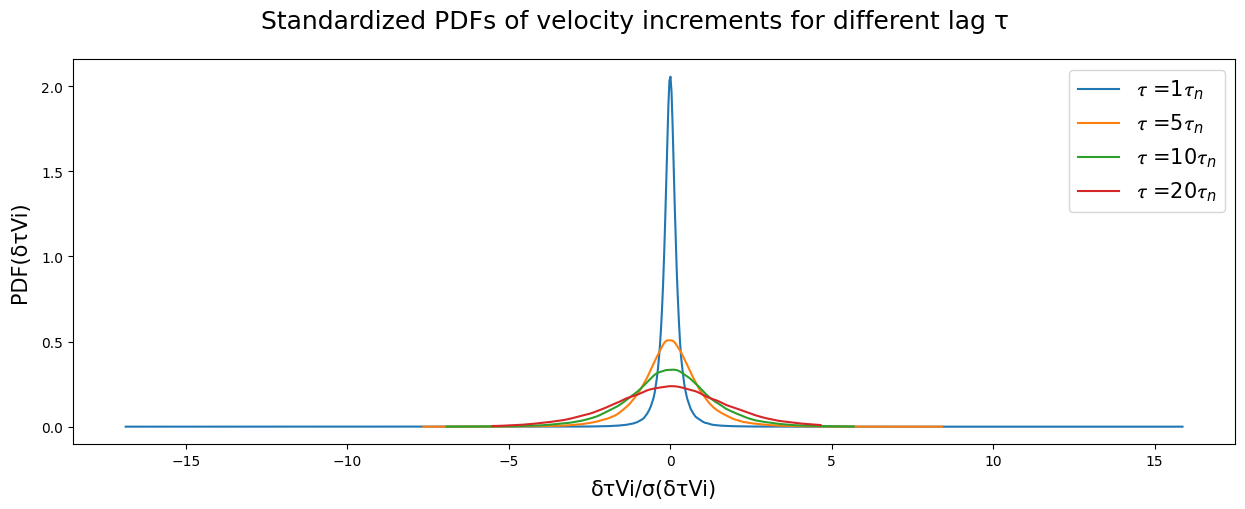

In [9]:
tau_values = [10,50,100,200]
plot_pdf_increments(velocities, tau_values)

### 1.2.3. Lagrangian structure function and flatness

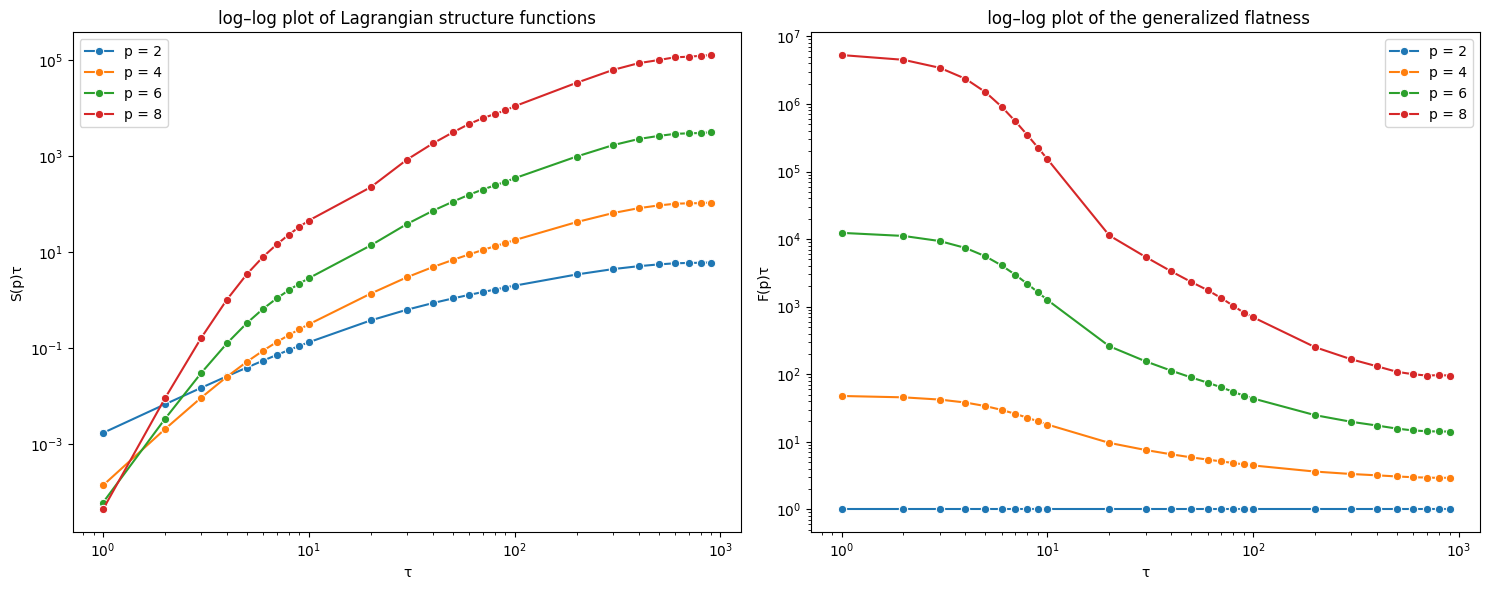

In [ ]:
tau_values = [i * 10**j for j in range(3) for i in range(1,10)]
p_values = [2,4,6,8]

plot_structure_flatness(velocities, p_values, tau_values)

# 2. Forward Process

In [4]:
train_normalized = normalize(train, max, min)
validation_normalized = normalize(validation, max, min)
test_normalized = normalize(test, max, min)

## 2.1. Variance schedulers

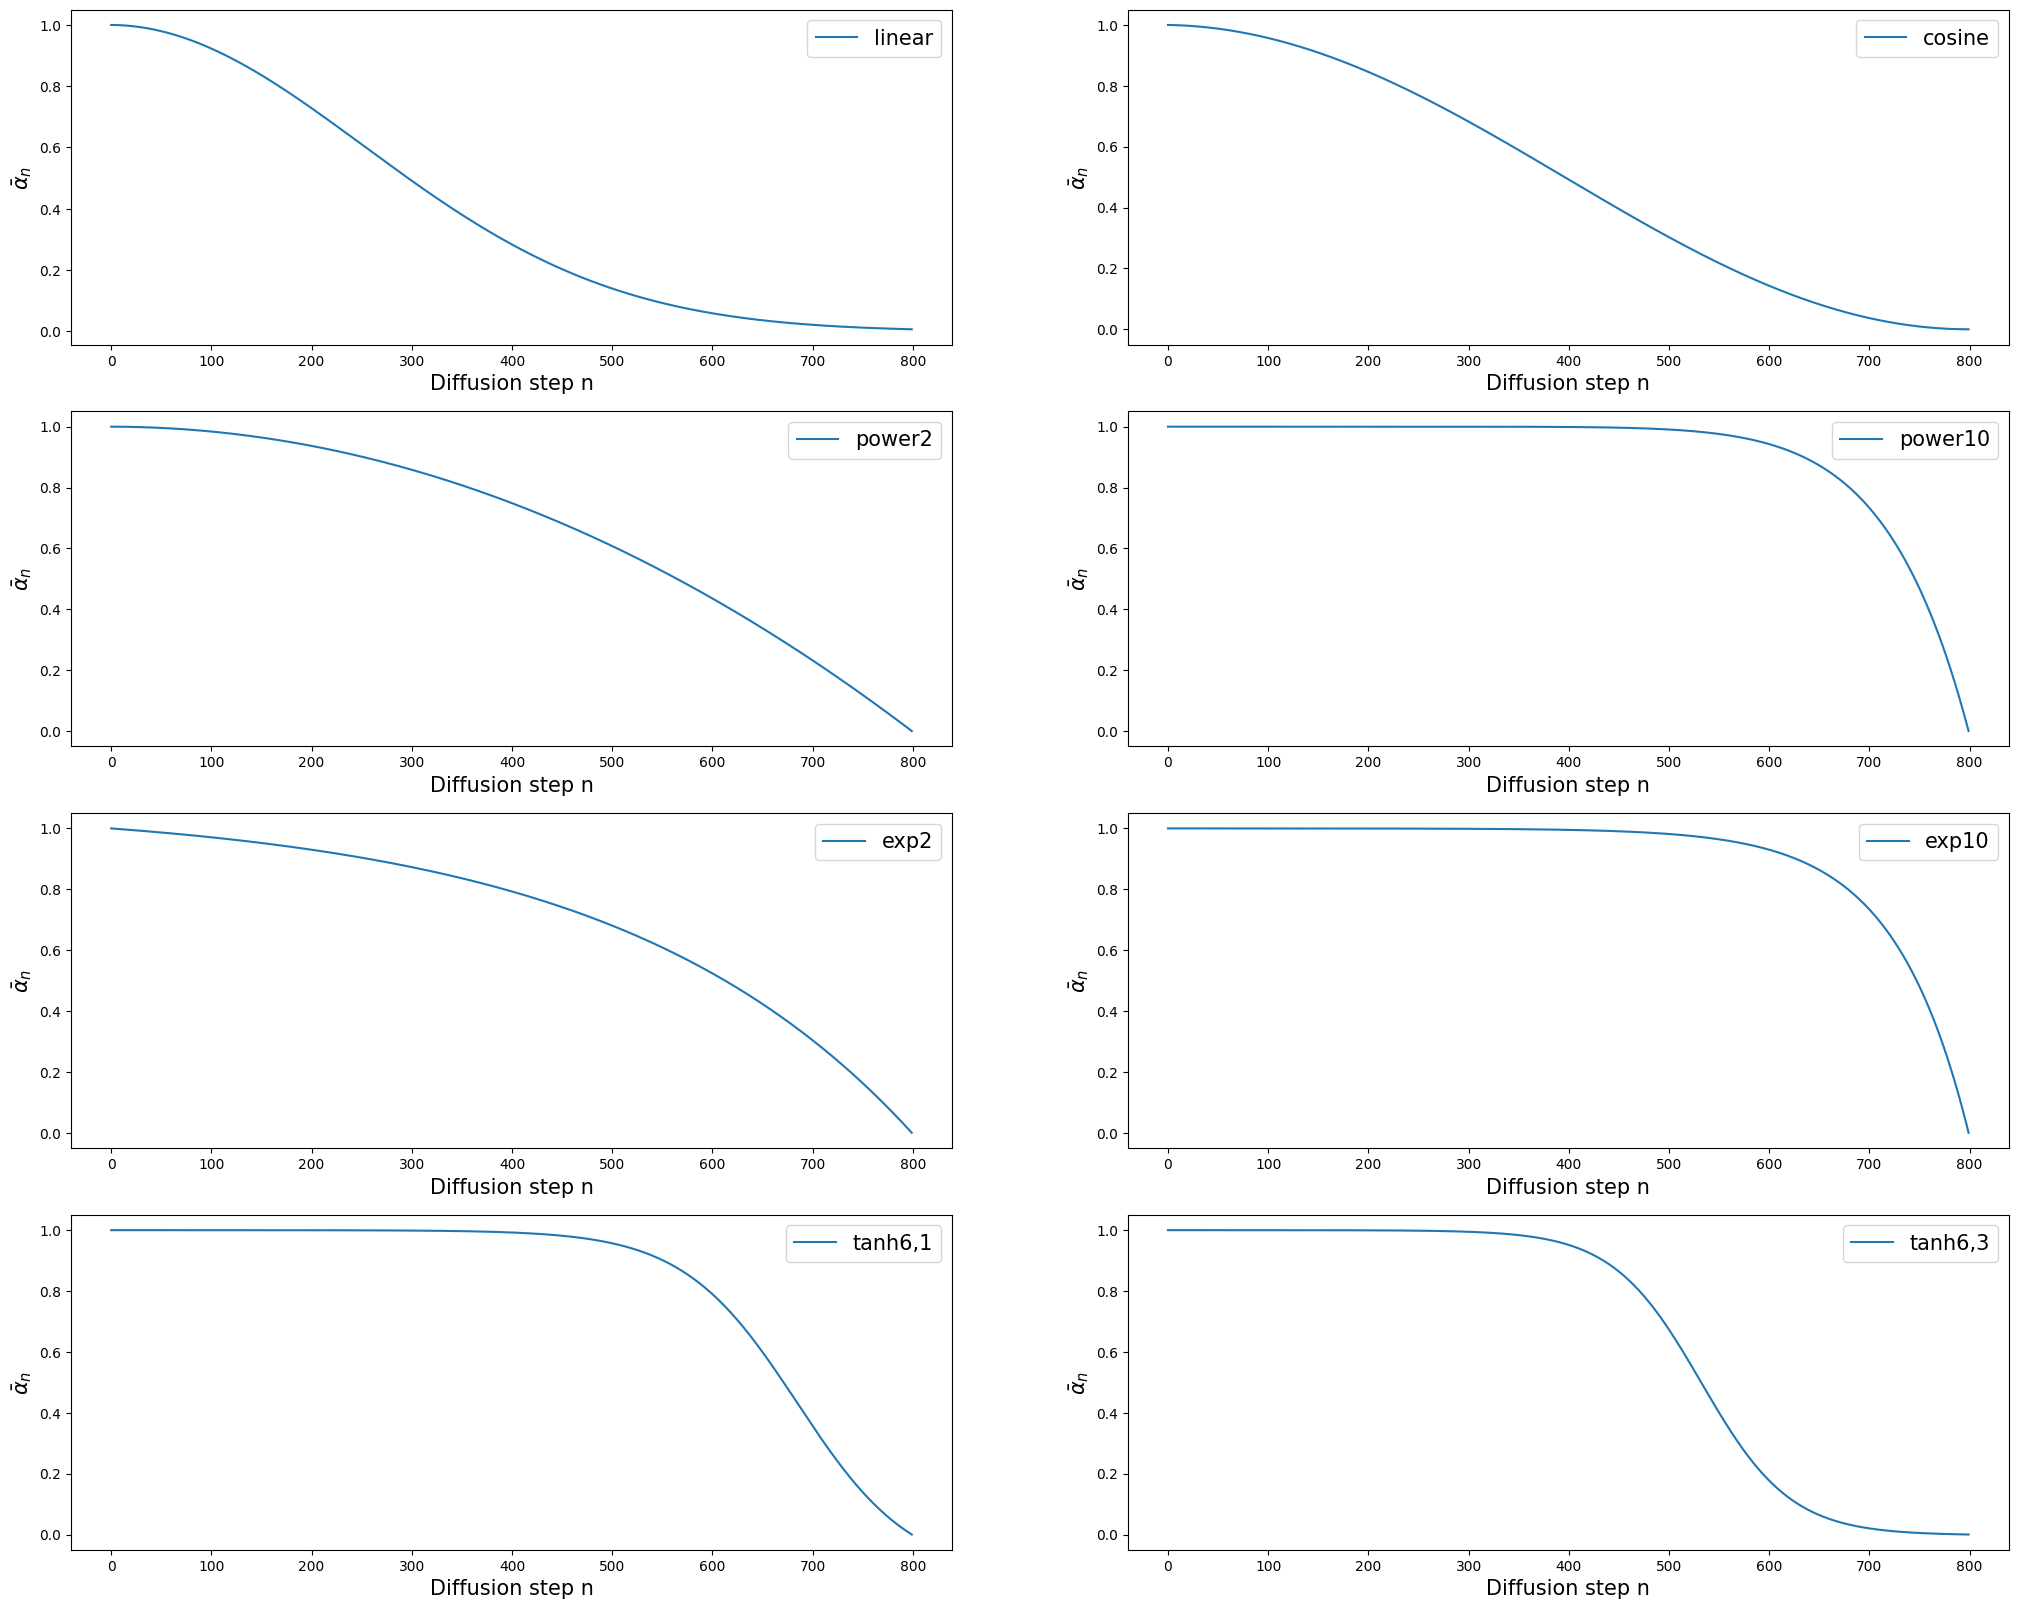

In [7]:
# Number of diffusion steps
N = 800
# Noise schedules
noise_schedules = ['linear', 'cosine', 'power2', 'power10', 'exp2', 'exp10', 'tanh6,1', 'tanh6,3']

fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(25,20))
axes = axes.flatten()
for (i,schedule) in enumerate(noise_schedules):
    betas = get_named_beta_schedule(schedule, N)
    alpha_bar = np.cumprod(1-betas, axis=0)
    sns.lineplot(x = np.arange(N),
                 y = alpha_bar,
                 ax = axes[i],
                 label = schedule)
    axes[i].set_xlabel('Diffusion step n', fontsize=15)
    axes[i].set_ylabel(r'$\bar{\alpha}_n$', fontsize=15)
    axes[i].tick_params('x', labelsize=10)
    axes[i].tick_params('y', labelsize=10)
    axes[i].legend(fontsize=15)

## 2.2. Adding noise to time series

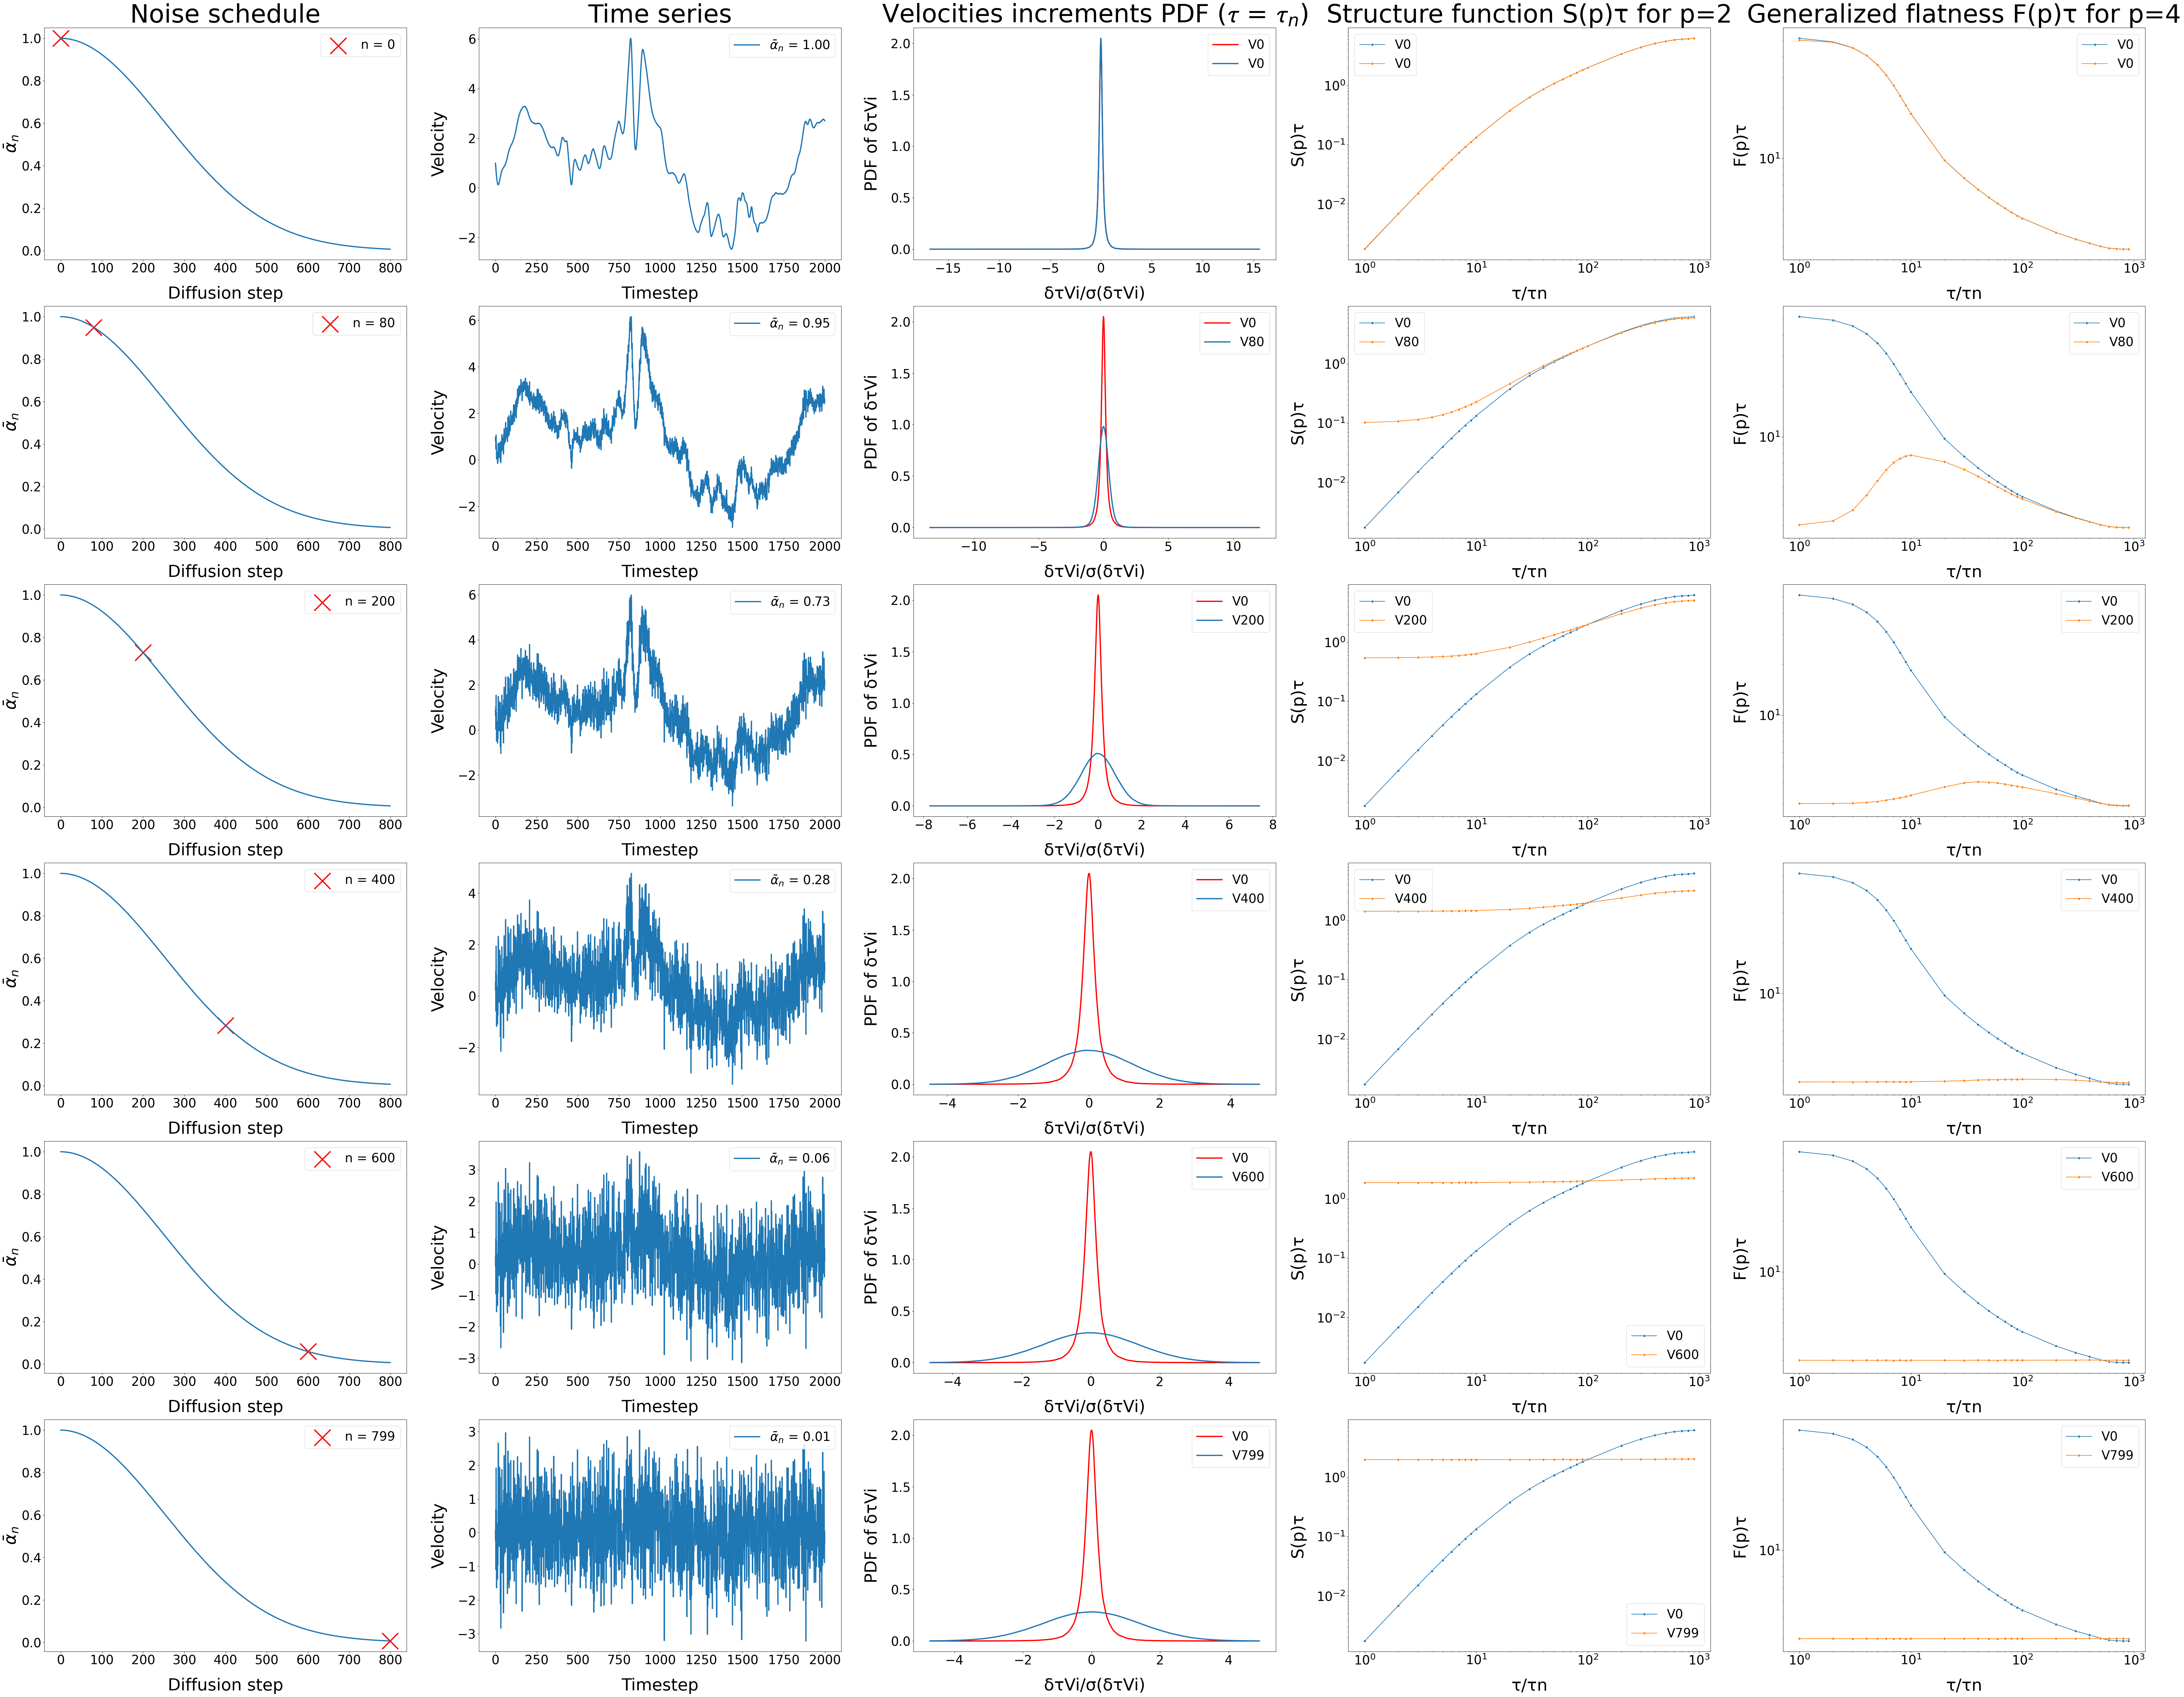

In [6]:
V0 = train
N = 800
schedule_name = 'linear'
diffusion_steps_ratio = [0,0.1,0.25,0.5,0.75,1]

plot_forward(V0=V0, num_diffusion_steps=N, schedule_name=schedule_name, diffusion_steps_ratio=diffusion_steps_ratio)

# 3. Backward process

In [5]:
input_channels = 1
model_channels = 64
output_channels = 1
n_heads=4
channels_mult = [1,2,4,8]

unet = UNet(input_channels, model_channels, output_channels, n_heads=n_heads, channels_mult=channels_mult)
unet

UNet(
  (encoder): ModuleList(
    (0): TimeSequentialEmbedding(
      (0): Conv1d(1, 64, kernel_size=(3,), stride=(1,), padding=(1,))
    )
    (1-3): 3 x TimeSequentialEmbedding(
      (0): Residual_block(
        (in_layers): Sequential(
          (0): GroupNorm(32, 64, eps=1e-05, affine=True)
          (1): SiLU()
          (2): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(1,))
        )
        (emb_layers): Sequential(
          (0): SiLU()
          (1): Linear(in_features=256, out_features=64, bias=True)
        )
        (out_layers): Sequential(
          (0): GroupNorm(32, 64, eps=1e-05, affine=True)
          (1): SiLU()
          (2): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(1,))
        )
        (skip_connection): Identity()
      )
    )
    (4): TimeSequentialEmbedding(
      (0): DownSample(
        (conv): Conv1d(64, 128, kernel_size=(2,), stride=(2,))
      )
    )
    (5-7): 3 x TimeSequentialEmbedding(
      (0): Residual_block(
        (in

## 3.1. Training

In [6]:
N = 800
schedule_name = 'linear'
device = th.device('cuda') if th.cuda.is_available() else th.device('cpu')
betas = get_named_beta_schedule(schedule_name, N)
model_diffusion = GaussianDiffusion(betas, device)
batch_size = 32
loss_type = 'mse'
num_steps=500
save_model_directory = "ddpm/"
validation_step = 25

# Train the UNet
train_loop = Train_loop(model=unet, diffusion=model_diffusion, train=train_normalized, validation=validation_normalized, batch_size=batch_size, device=device, loss_type=loss_type, num_steps=num_steps)
train_losses, validation_losses = train_loop.run_loop(save_model_directory, validation_step)

Training start of 500 steps on device cuda
iteration 0 | training loss: 0.9995 | validation loss: 0.9962 | learning rate: 9.9999e-05
Save the model : validation loss: 0.9962
iteration 1 | training loss : 0.9960 | learning rate: 9.9996e-05
iteration 2 | training loss : 0.9891 | learning rate: 9.9991e-05
iteration 3 | training loss : 0.9779 | learning rate: 9.9984e-05
iteration 4 | training loss : 0.9682 | learning rate: 9.9975e-05
iteration 5 | training loss : 0.9558 | learning rate: 9.9965e-05
iteration 6 | training loss : 0.9438 | learning rate: 9.9952e-05
iteration 7 | training loss : 0.9391 | learning rate: 9.9937e-05
iteration 8 | training loss : 0.9170 | learning rate: 9.9920e-05
iteration 9 | training loss : 0.9152 | learning rate: 9.9901e-05
iteration 10 | training loss : 0.9121 | learning rate: 9.9881e-05
iteration 11 | training loss : 0.8905 | learning rate: 9.9858e-05
iteration 12 | training loss : 0.8844 | learning rate: 9.9833e-05
iteration 13 | training loss : 0.8699 | lea

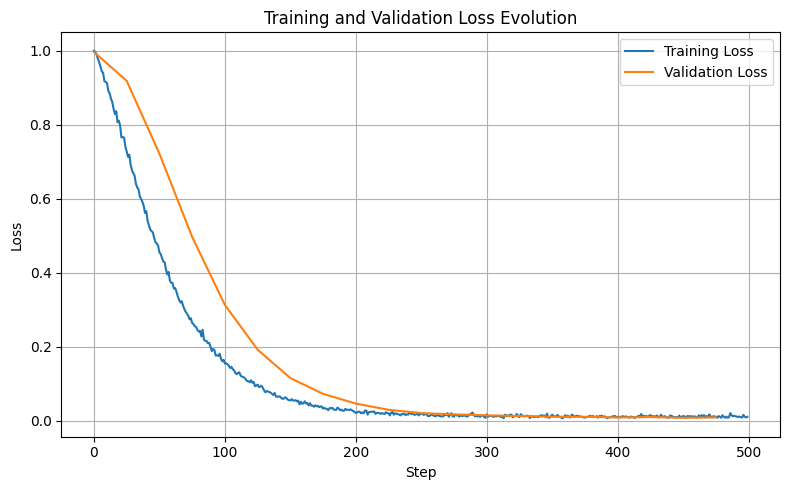

In [7]:
# Plot the training and validation losses
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(np.arange(len(train_losses)), train_losses, label='Training Loss')
ax.plot(np.arange(0, len(train_losses), validation_step), validation_losses, label='Validation Loss')
ax.set_xlabel("Step")
ax.set_ylabel("Loss")
ax.set_title(f"Training and Validation Loss Evolution")
ax.legend()
ax.grid()
plt.tight_layout()
plt.show()

## 3.2. Sampling

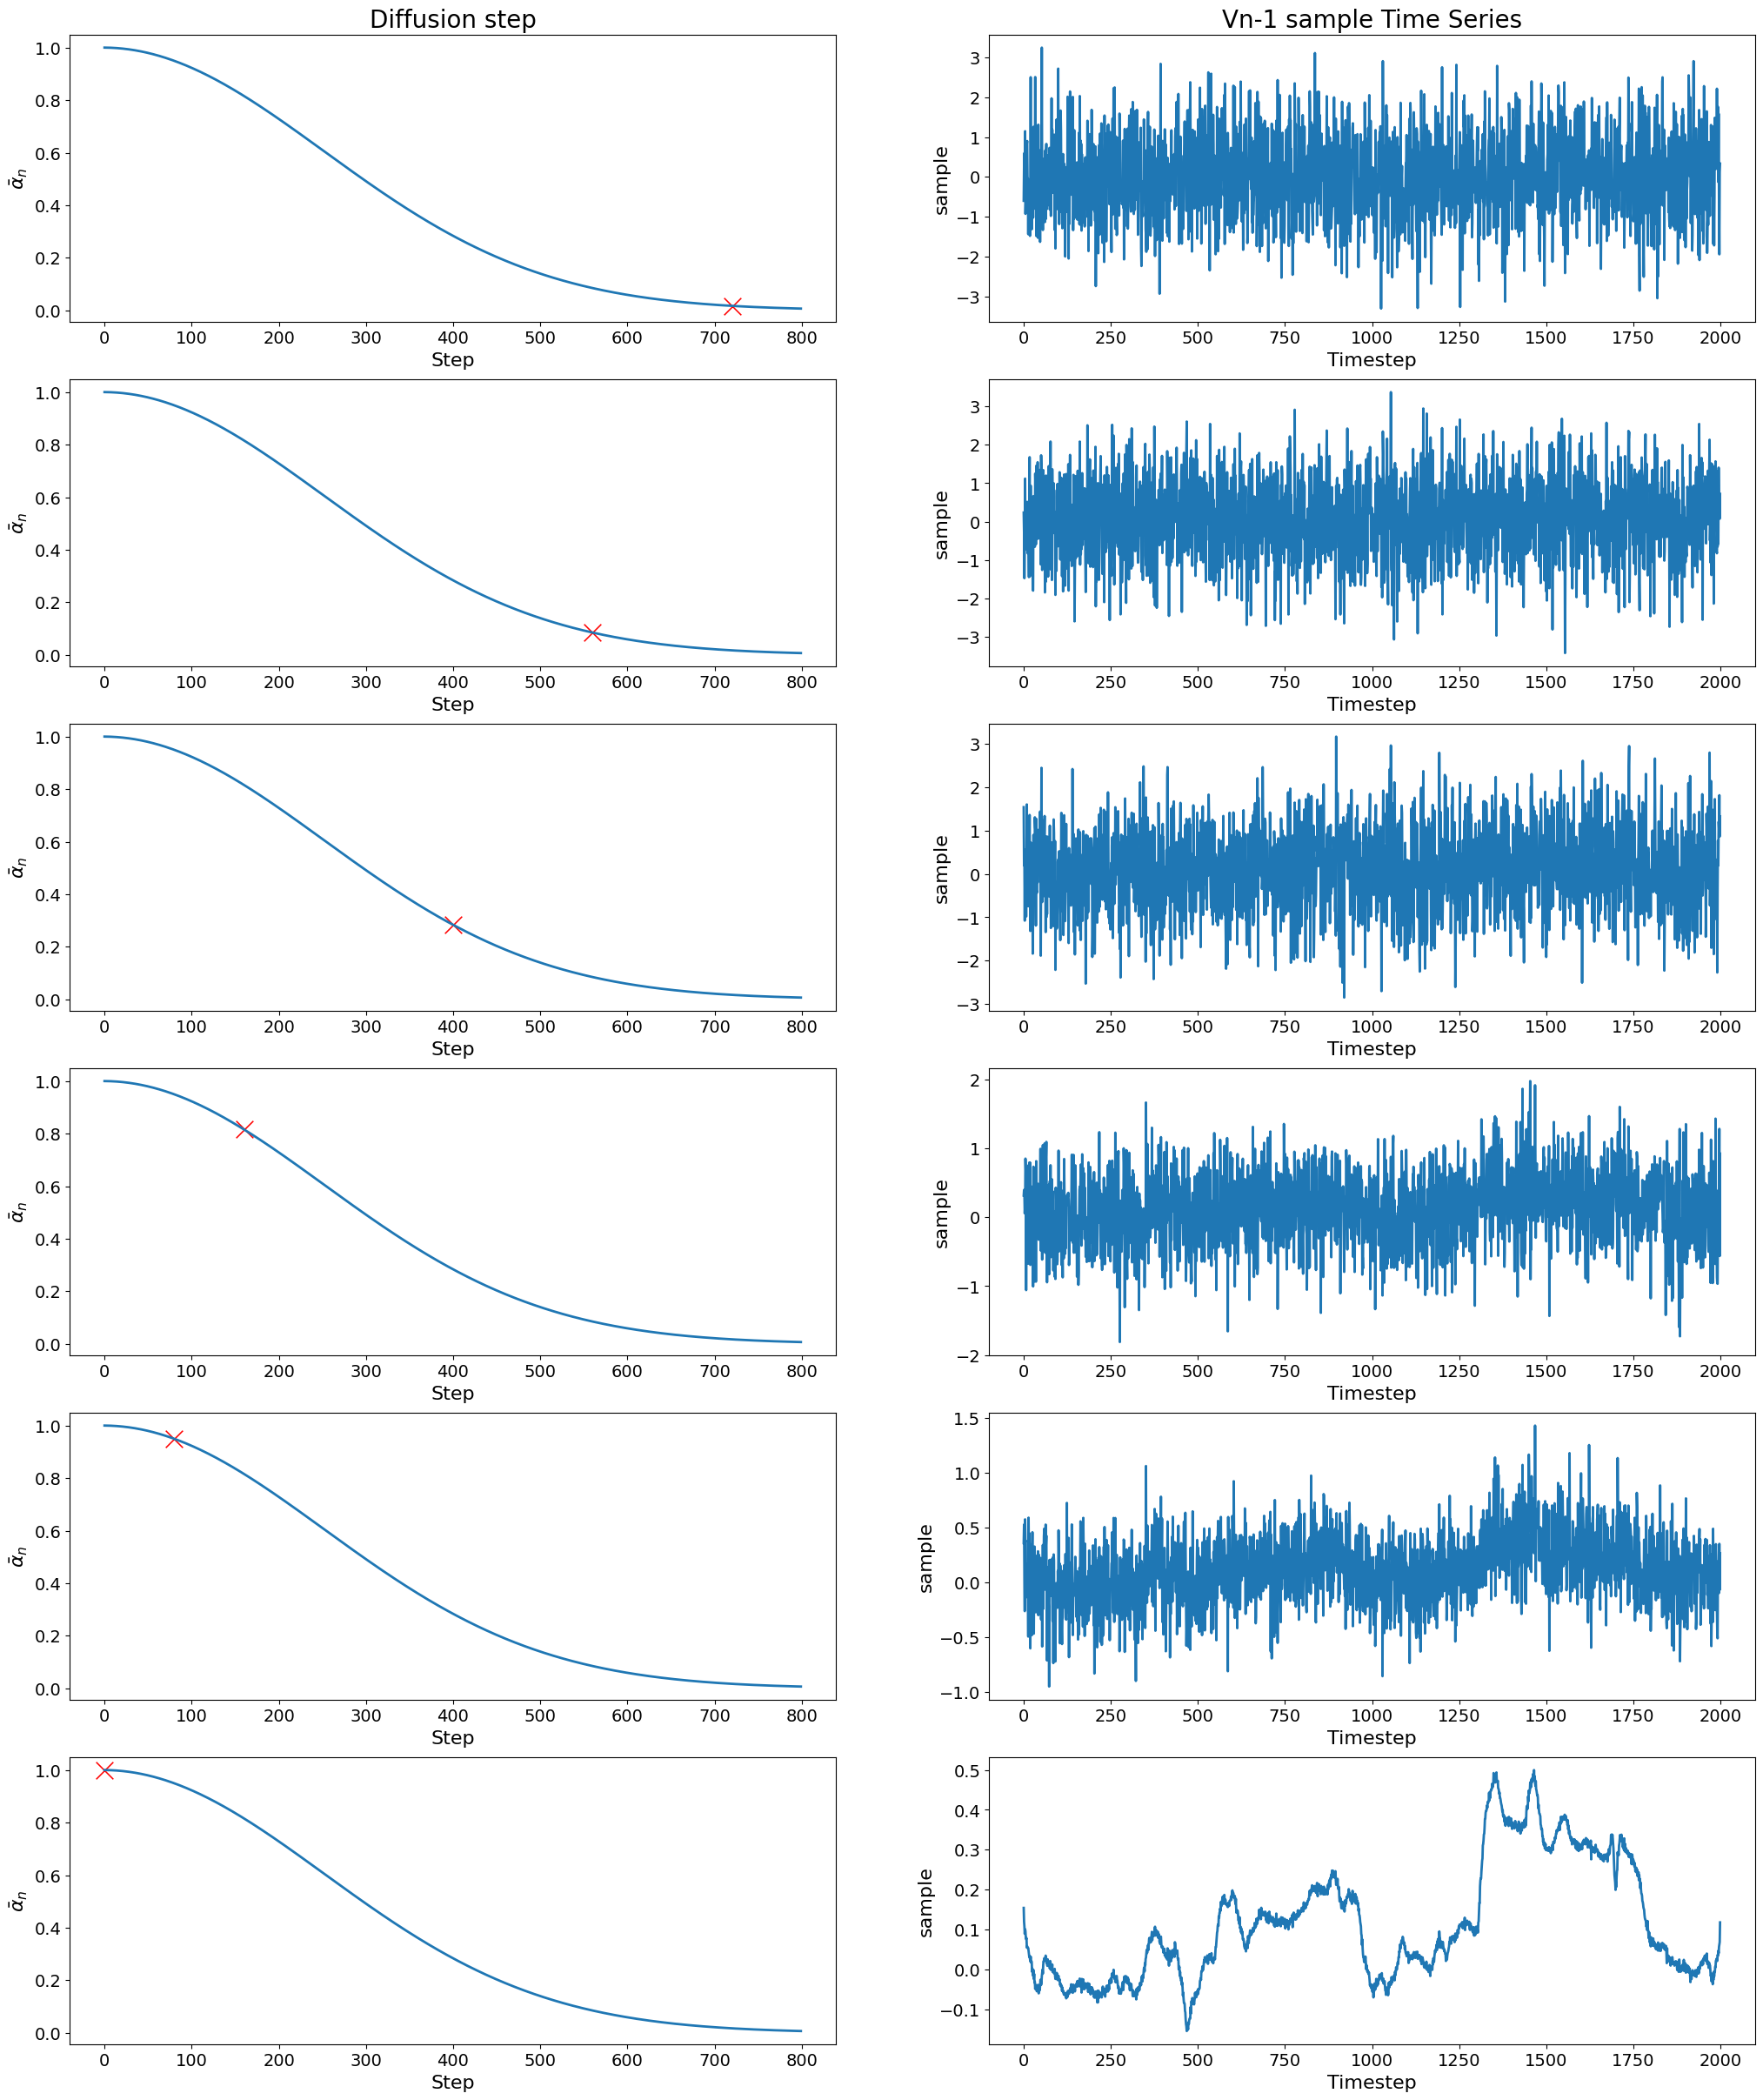

In [6]:
N = 800
schedule_name = 'linear'
betas = get_named_beta_schedule(schedule_name, N)
device = th.device('cuda') if th.cuda.is_available() else th.device('cpu')
model_diffusion = GaussianDiffusion(betas, device)
input_channels = 1
model_channels = 64
output_channels = 1
n_heads=4
channels_mult = [1,2,4,8]

# Load the trained UNet
unet = UNet(input_channels, model_channels, output_channels, n_heads=n_heads, channels_mult=channels_mult)
unet.load_state_dict(th.load("ddpm/best_unet.pth"))
unet.eval()

# Denoise and sample at each diffusion step 
noise = th.randn_like(train[0].unsqueeze(0), device=device)
sample_loop = Sample_loop(unet, betas, noise, device=device)
output_loader = sample_loop.run_loop_generator()
outputs = {}
for output in output_loader:
    if outputs == {}: 
        outputs = {k : [] for k in output.keys()} 
    for k,v in output.items():
        outputs[k].append(v)

# Plot the backward evolution of the predicted parameter
parameter = 'sample'
plot_backward(outputs, parameter, model_diffusion)

# 4. Test

## 4.1. Generate samples

In [7]:
num_samples = 250
N = 800
schedule_name = 'linear'
betas = get_named_beta_schedule(schedule_name, N)
device = th.device('cuda') if th.cuda.is_available() else th.device('cpu')
model_diffusion = GaussianDiffusion(betas, device)
input_channels = 1
model_channels = 64
output_channels = 1
n_heads=4
channels_mult = [1,2,4,8]

# Load the trained UNet
unet = UNet(input_channels, model_channels, output_channels, n_heads=n_heads, channels_mult=channels_mult)
unet.load_state_dict(th.load("ddpm/best_unet.pth"))
unet.eval()

generated_samples = []

# Loop over the number of samples
for _ in range(num_samples):

    # Denoise across all the diffusion steps to generate final prediction
    noise = th.randn_like(train[0].unsqueeze(0), device=device)
    sample_loop = Sample_loop(unet, betas, noise, device=device)
    V0_sample = sample_loop.run_loop_last_sample()
    generated_samples.append(V0_sample.detach().cpu().numpy())

generated_samples = np.concatenate(generated_samples, axis=0)

## 4.2. Performance metrics

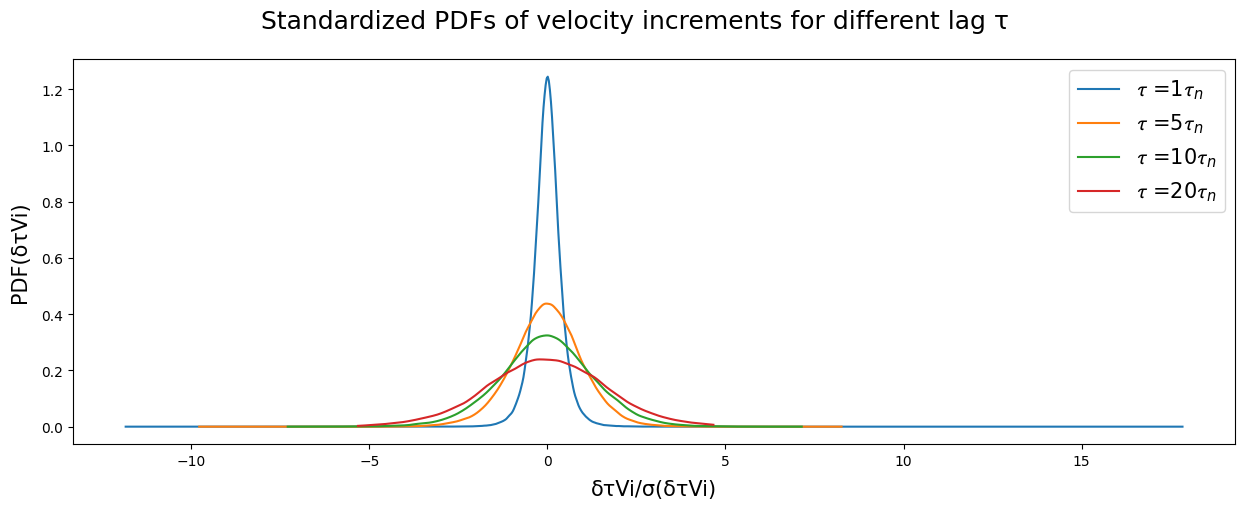

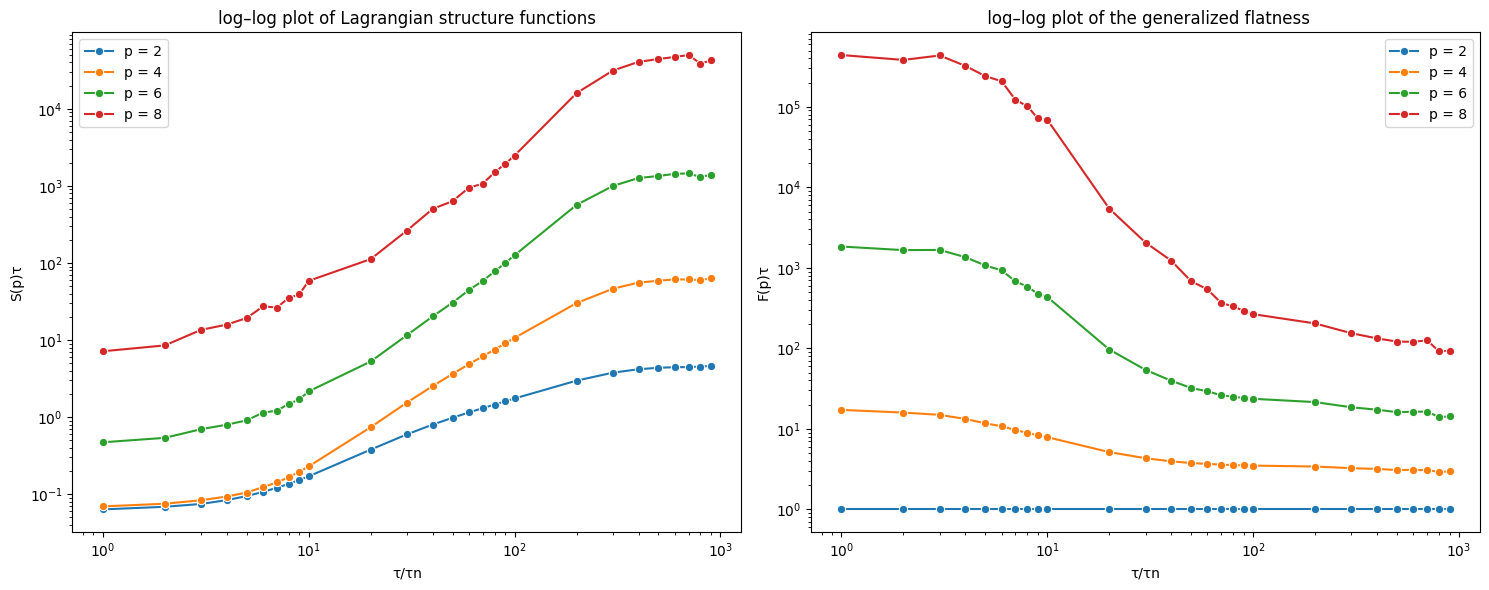

In [8]:
generated_velocities = denormalize(generated_samples, max, min)

tau_values = [10,50,100,200]
plot_pdf_increments(generated_velocities, tau_values)

tau_values = [i * 10**j for j in range(3) for i in range(1,10)]
p_values = [2,4,6,8]
plot_structure_flatness(generated_velocities, p_values, tau_values)